In [1]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [3]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../../MeshPipeline/outputs/initialFEAstuff/35T') # path to parent of output_root in set_parameters
study_prefix = '35T' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs') # path dir to save outputs in
suffixes = ['a', 'b'] # individual study identifier (end of dir name of output_root in set_parameters)

In [4]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.optimisation.odt',
    'cgal_params.optimisation.lloyd',
    ]
get_params3d(root_dir, study_prefix, suffixes, extra_params).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [5]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [6]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'
qual_part2 = 'cart_inner'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        f'{qual_part2}_min_angle_worst',
        f'{qual_part2}_scaled_jacobian_worst',
        f'{qual_part2}_aspect_ratio_worst',
        f'{qual_part2}_radius_ratio_worst',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)
df = df[(df['bone_remesh2d_di_max']<0.1)&(df['cart_remesh2d_di_max']<0.1)&(df['full_scaled_jacobian_worst']>0.04)] # remove any where odt chipped tets

#df = df[df['bone']==bone]

print(len(df))

47


Highest element count:
	50000R - 293735


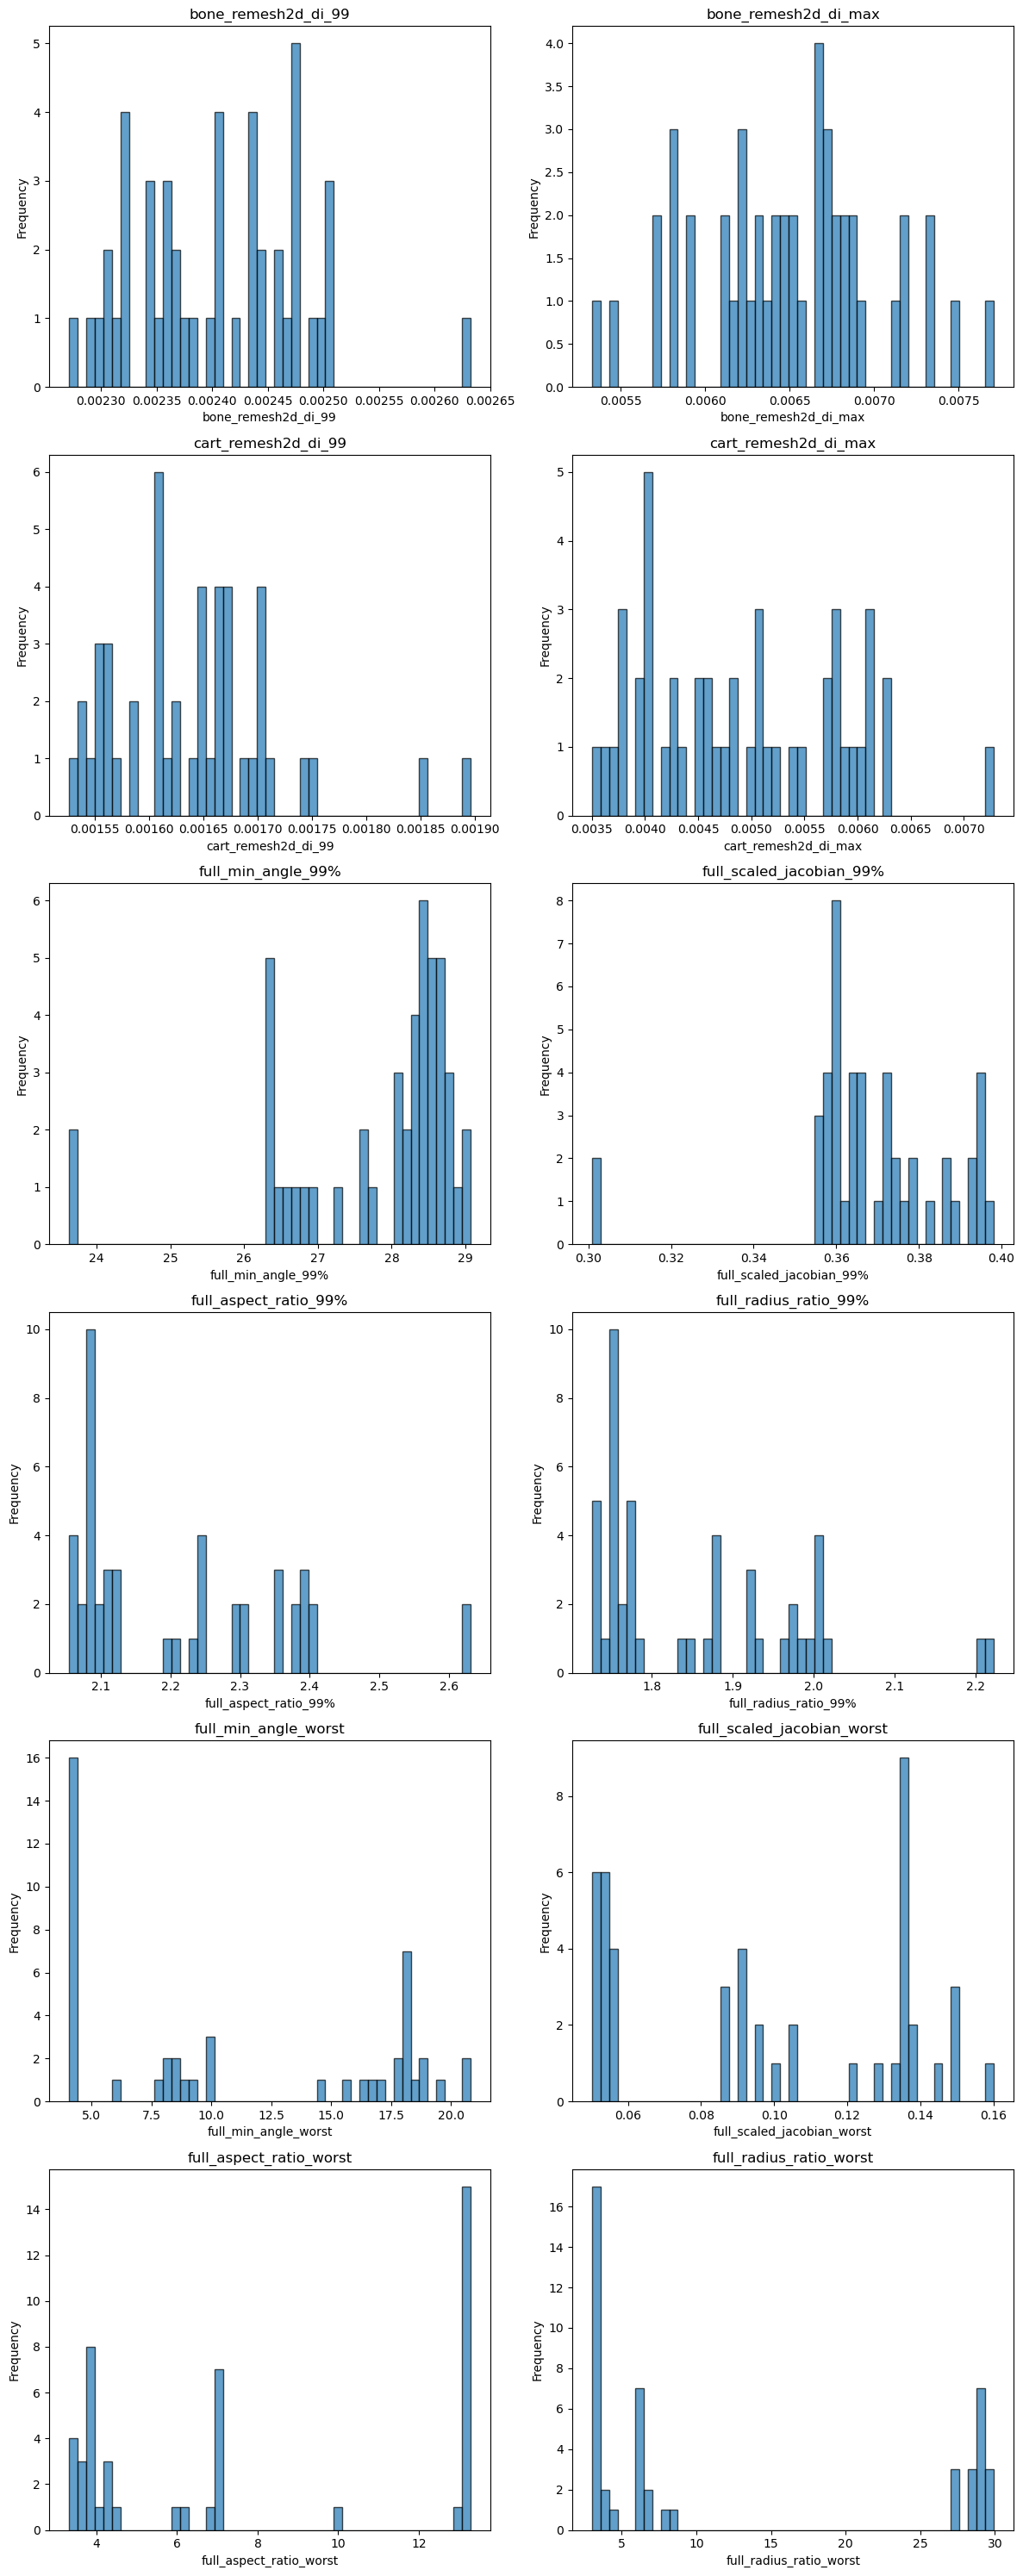

In [7]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 1)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [8]:
q1_weight = 10
q2_weight = 25
q3_weight = 50

chosen_metrics = {

    f'{qual_part2}_min_angle_worst': {
        'ideal': 20,
        'acceptable': 15,
        'weight': q3_weight
    },

    f'{qual_part2}_scaled_jacobian_worst': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q3_weight
    },

    f'{qual_part2}_aspect_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },

    f'{qual_part2}_radius_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },




    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q2_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q2_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q1_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q1_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },
}

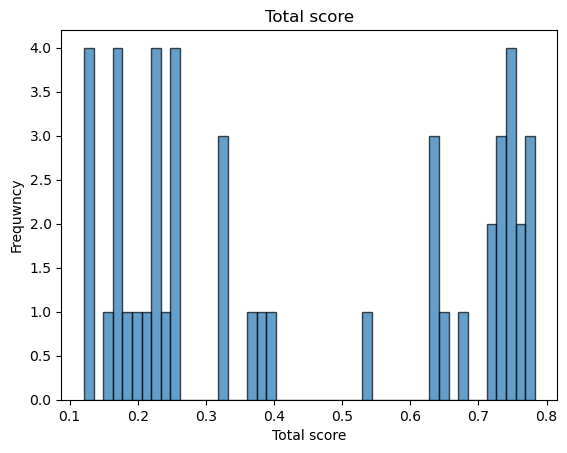

In [9]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_qual.merge(
    df_score,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/1), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [10]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,mean_rank,median_rank,best_rank,n_runs
21,True,False,NaN,NaN,30.0,0.0001,5.5,5.5,3.0,2
19,True,False,NaN,NaN,20.0,0.0010,6.5,6.5,1.0,2
17,True,False,NaN,NaN,20.0,0.0001,6.5,6.5,2.0,2
18,True,False,NaN,NaN,20.0,0.0005,7.5,7.5,5.0,2
0,False,False,NaN,NaN,NaN,NaN,9.0,9.0,5.0,2
22,True,False,NaN,NaN,30.0,0.0005,9.0,9.0,9.0,2
14,True,False,NaN,NaN,10.0,0.0005,10.0,10.0,6.0,2
13,True,False,NaN,NaN,10.0,0.0001,10.0,10.0,7.0,2
20,True,False,NaN,NaN,20.0,0.0100,10.5,10.5,4.0,2
11,False,True,30.0,0.001,NaN,NaN,10.5,10.5,3.0,2


In [11]:
best_per_tet = df_score_param.groupby(['sub', 'bone']).first()
best_per_tet

run_id  cart_inner_min_angle_worst  \
sub    bone                                          
50000R mc1    0-0-5-0b                         1.0   
       tpm   0-0-11-0a                         1.0   

             cart_inner_scaled_jacobian_worst  cart_inner_aspect_ratio_worst  \
sub    bone                                                                    
50000R mc1                           0.034926                       0.973113   
       tpm                           0.181612                       0.829738   

             cart_inner_radius_ratio_worst  full_min_angle_worst  \
sub    bone                                                        
50000R mc1                         1.00000                   1.0   
       tpm                         0.93238                   1.0   

             full_scaled_jacobian_worst  full_aspect_ratio_worst  \
sub    bone                                                        
50000R mc1                     0.113674                      1.0   
       tpm                     0.150830                      1.0   

             full_radius_ratio_worst  full_min_angle_99%  ...  \
sub    bone                                               ...   
50000R mc1                       1.0            0.968980  ...   
       tpm                       1.0            0.955198  ...   

             full_aspect_ratio_99%  full_radius_ratio_99%     total  \
sub    bone                                                           
50000R mc1                     1.0                    1.0  0.782823   
       tpm                     1.0                    1.0  0.780629   

             rank_within_case  cgal_params.optimisation.odt  \
sub    bone                                                   
50000R mc1                1.0                          True   
       tpm                1.0                         False   

             cgal_params.optimisation.lloyd  \
sub    bone                                   
50000R mc1                            False   
       tpm                             True   

             cgal_params.lloyd.max_iteration_number  \
sub    bone                                           
50000R mc1                                     10.0   
       tpm                                     30.0   

             cgal_params.lloyd.freeze_bound  \
sub    bone                                   
50000R mc1                           0.0010   
       tpm                           0.0001   

             cgal_params.odt.max_iteration_number  \
sub    bone                                         
50000R mc1                                   20.0   
       tpm                                   30.0   

             cgal_params.odt.freeze_bound  
sub    bone                                
50000R mc1                          0.001  
       tpm                          0.001  

[2 rows x 21 columns]

In [12]:
best_per_tet.merge(df_score_qual)[['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_x' in x]]

,sub,bone,run_id,full_min_angle_worst_x,full_min_angle_99%_x,full_radius_ratio_worst_x,full_radius_ratio_99%_x,full_aspect_ratio_worst_x,full_aspect_ratio_99%_x,full_scaled_jacobian_worst_x,full_scaled_jacobian_99%_x,cart_inner_min_angle_worst_x,cart_inner_radius_ratio_worst_x,cart_inner_aspect_ratio_worst_x,cart_inner_scaled_jacobian_worst_x
0,50000R,mc1,0-0-5-0b,20.797962,29.069414,3.055188,1.726623,3.321183,2.055119,0.150624,0.364521,21.013023,2.501515,3.053773,0.211287
1,50000R,tpm,0-0-11-0a,19.441088,28.655954,3.454731,1.837043,3.363079,2.201247,0.160052,0.398096,20.024427,3.135239,3.340524,0.266242
